In [1]:
import pandas as pd
import numpy as np
import os
import re
from PyPDF2 import PdfReader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

C:\Users\magic\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [4]:
df.shape

(2484, 4)

In [5]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

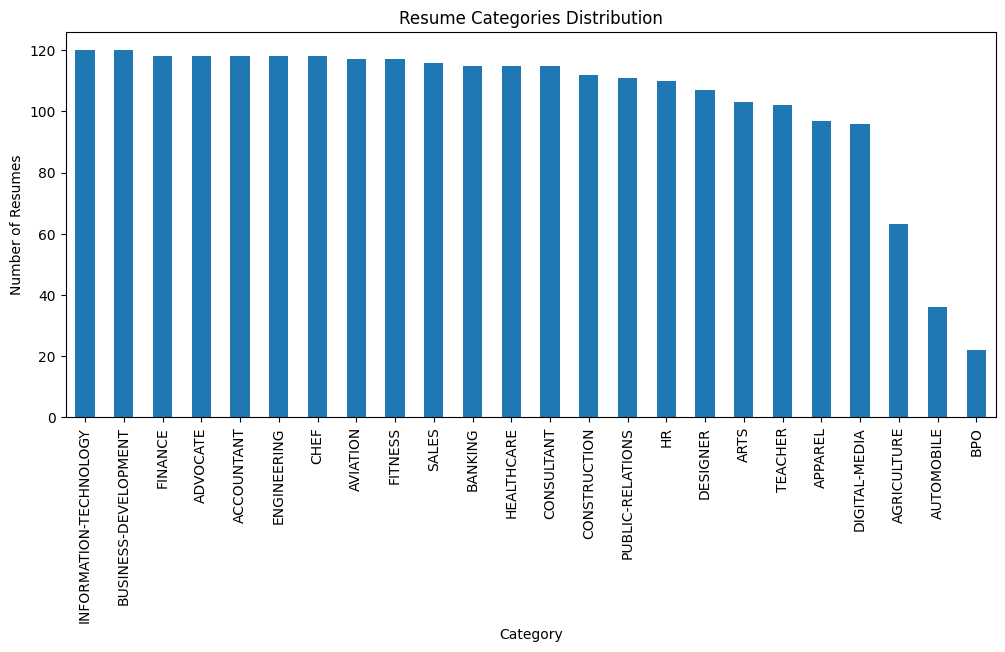

In [6]:
import matplotlib.pyplot as plt
df['Category'].value_counts().plot(
    kind='bar',
    figsize=(12,5))
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.title("Resume Categories Distribution")
plt.show()

In [7]:
df['Resume_str'][0]

"         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    
    return text

In [9]:
df['clean_resume'] = df['Resume_str'].apply(clean_text)

df[['Resume_str','clean_resume']].head()

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admin...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versat...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in ...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dy...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depa...


In [10]:
df['clean_resume'][0]

' hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment experience hr administrator marketing 

In [11]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\magic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
print(list(stop_words)[:10])

['each', 'only', "he'd", 'wouldn', 'than', 'our', 'y', 'more', 'the', 'with']


In [13]:
def remove_stopwords(text):
    
    words = text.split()
    
    filtered_words = [
        word for word in words 
        if word not in stop_words
    ]
    
    return " ".join(filtered_words)

In [14]:
df['clean_resume'] = df['clean_resume'].apply(remove_stopwords)

df['clean_resume'][0]

'hr administrator marketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction team management marketing savvy conflict resolution techniques training development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplished trainer cross server hospitality systems hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses seminars customer service sales strategies inventory control loss prevention safety time management leadership performance assessment experience hr administrator marketing associate hr administrator dec current company name city state helps devel

In [15]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\magic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
from nltk.tokenize import word_tokenize
tokens = word_tokenize(df['clean_resume'][0])

tokens[:20]

['hr',
 'administrator',
 'marketing',
 'associate',
 'hr',
 'administrator',
 'summary',
 'dedicated',
 'customer',
 'service',
 'manager',
 'years',
 'experience',
 'hospitality',
 'customer',
 'service',
 'management',
 'respected',
 'builder',
 'leader']

In [17]:
id="r4g6j9"
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\magic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\magic\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
id="7m2j9p"
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [19]:
id="4n2x9s"
def lemmatize_text(tokens):
    lemmatized_words = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    
    return lemmatized_words

In [20]:
id="m8d3kf"
tokens = word_tokenize(df['clean_resume'][0])

lemma_tokens = lemmatize_text(tokens)

lemma_tokens[:20]

['hr',
 'administrator',
 'marketing',
 'associate',
 'hr',
 'administrator',
 'summary',
 'dedicated',
 'customer',
 'service',
 'manager',
 'year',
 'experience',
 'hospitality',
 'customer',
 'service',
 'management',
 'respected',
 'builder',
 'leader']

In [23]:
df["processed_resume"] = df["clean_resume"]
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df["processed_resume"])

In [24]:
tfidf_matrix.shape

(2484, 37586)

In [35]:
job_description = """
We are looking for an HR specialist with experience in
employee relations, recruitment, training, payroll,
human resources management and administration.
"""

In [36]:
job_vector = tfidf.transform([job_description])

In [37]:
similarity_scores = cosine_similarity(job_vector, tfidf_matrix)

In [38]:
df["Match_Score"] = similarity_scores[0] * 100

df[["Category", "Match_Score"]].head()

,Category,Match_Score
0,HR,21.538427
1,HR,14.728730
2,HR,26.792858
3,HR,12.681633
4,HR,39.115874


In [39]:
ranked_resumes = df.sort_values(
    by="Match_Score",
    ascending=False
)

ranked_resumes[
    ["Category", "Match_Score"]
].head(10)

,Category,Match_Score
55,HR,42.092973
95,HR,39.152545
4,HR,39.115874
52,HR,38.589247
24,HR,37.866988
14,HR,37.313100
101,HR,37.148294
27,HR,36.829594
81,HR,36.576045
85,HR,36.460185


In [40]:
top_candidates = ranked_resumes.head(10)

top_candidates[["Category", "Match_Score"]]

,Category,Match_Score
55,HR,42.092973
95,HR,39.152545
4,HR,39.115874
52,HR,38.589247
24,HR,37.866988
14,HR,37.313100
101,HR,37.148294
27,HR,36.829594
81,HR,36.576045
85,HR,36.460185


In [41]:
shortlisted = ranked_resumes[
    ranked_resumes["Match_Score"] > 10
]

shortlisted[["Category", "Match_Score"]]

,Category,Match_Score
55,HR,42.092973
95,HR,39.152545
4,HR,39.115874
52,HR,38.589247
24,HR,37.866988
...,...,...
1865,ACCOUNTANT,10.172524
450,ADVOCATE,10.133746
973,BPO,10.058691
1513,FINANCE,10.041967


In [42]:
shortlisted_candidates = ranked_resumes[
    ranked_resumes["Match_Score"] >= 30
]


shortlisted_candidates[
    ["Category", "Match_Score"]
]

,Category,Match_Score
55,HR,42.092973
95,HR,39.152545
4,HR,39.115874
52,HR,38.589247
24,HR,37.866988
14,HR,37.313100
101,HR,37.148294
27,HR,36.829594
81,HR,36.576045
85,HR,36.460185


In [43]:
shortlisted_candidates.shape

(38, 7)

In [44]:
shortlisted_candidates.head(5)

,ID,Resume_str,Resume_html,Category,clean_resume,processed_resume,Match_Score
55,30862904,HR MANAGER Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager highlights senior human resources s...,hr manager highlights senior human resources s...,42.092973
95,28640735,DIRECTOR OF HR Executive Pr...,"<div class=""fontsize fontface vmargins hmargin...",HR,director hr executive profile ambitious human ...,director hr executive profile ambitious human ...,39.152545
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,hr manager skill highlights hr skills hr depar...,39.115874
52,72231872,HR GENERALIST Professional Summ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr generalist professional summary years exper...,hr generalist professional summary years exper...,38.589247
24,87968870,HR GENERALIST Summary Ener...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr generalist summary energetic bilingual huma...,hr generalist summary energetic bilingual huma...,37.866988


In [45]:
ranking_output = ranked_resumes[
    ["ID", "Category", "Match_Score"]
].head(10)

ranking_output

,ID,Category,Match_Score
55,30862904,HR,42.092973
95,28640735,HR,39.152545
4,17812897,HR,39.115874
52,72231872,HR,38.589247
24,87968870,HR,37.866988
14,27490876,HR,37.313100
101,28175164,HR,37.148294
27,29297973,HR,36.829594
81,24508725,HR,36.576045
85,34740556,HR,36.460185


In [46]:
ranking_output = ranking_output.reset_index(drop=True)

ranking_output.index = ranking_output.index + 1

ranking_output

,ID,Category,Match_Score
1,30862904,HR,42.092973
2,28640735,HR,39.152545
3,17812897,HR,39.115874
4,72231872,HR,38.589247
5,87968870,HR,37.866988
6,27490876,HR,37.313100
7,28175164,HR,37.148294
8,29297973,HR,36.829594
9,24508725,HR,36.576045
10,34740556,HR,36.460185


In [47]:
shortlisted_candidates[
    ["ID", "Category", "Match_Score"]
].to_csv(
    "shortlisted_candidates.csv",
    index=False
)

In [49]:
import joblib
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [50]:
joblib.dump(tfidf_matrix, "tfidf_matrix.pkl")

['tfidf_matrix.pkl']

In [51]:
df.to_pickle("resume_data.pkl")